# IMPORTING LIBRARIES

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# SET FILE PATH AND DOWNLOAD DATASET

In [82]:
import os
import requests
import pandas as pd
from io import StringIO

# Load GitHub Token from environment variable (or store in .env)
token = os.getenv("GITHUB_TOKEN")

url = "https://raw.githubusercontent.com/SubharupBiswas/sih2025/main/crop_yield_dataset.csv"
headers = {"Authorization": f"token {token}"} if token else {}

# Load dataset locally if available, or fetch via URL
if os.path.exists("../datasets/crop_yield_dataset.csv"):
    df = pd.read_csv("../datasets/crop_yield_dataset.csv")
elif os.path.exists("ml/datasets/crop_yield_dataset.csv"):
    df = pd.read_csv("ml/datasets/crop_yield_dataset.csv")
elif os.path.exists("crop_yield_dataset.csv"):
    df = pd.read_csv("crop_yield_dataset.csv")
else:
    response = requests.get(url, headers=headers)
    df = pd.read_csv(StringIO(response.text))

print(df)   # (rows, columns)


             Date  Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
0      2014-01-01      Wheat     Peaty     5.50     9.440599  80.000000   
1      2014-01-01       Corn     Loamy     6.50    20.052576  79.947424   
2      2014-01-01       Rice     Peaty     5.50    12.143099  80.000000   
3      2014-01-01     Barley     Sandy     6.75    19.751848  80.000000   
4      2014-01-01    Soybean     Peaty     5.50    16.110395  80.000000   
...           ...        ...       ...      ...          ...        ...   
36515  2023-12-31     Cotton      Clay     6.25    19.538555  80.000000   
36516  2023-12-31  Sugarcane     Peaty     5.50    21.068336  78.931664   
36517  2023-12-31     Tomato     Sandy     6.75     6.030148  80.000000   
36518  2023-12-31     Potato     Peaty     5.50    11.079561  80.000000   
36519  2023-12-31  Sunflower      Clay     6.25    11.455692  80.000000   

       Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
0       10.956707  60.5  45.0  31.5

# STUDY DATASET AND DROP DUPLICATES

In [83]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

before_dupes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after_dupes = df.shape[0]
print(f"\nDropped duplicates: {before_dupes - after_dupes}")

Shape: (36520, 12)
Columns: ['Date', 'Crop_Type', 'Soil_Type', 'Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield', 'Soil_Quality']

Data types:
 Date             object
Crop_Type        object
Soil_Type        object
Soil_pH         float64
Temperature     float64
Humidity        float64
Wind_Speed      float64
N               float64
P               float64
K               float64
Crop_Yield      float64
Soil_Quality    float64
dtype: object

Missing values per column:
 Date            0
Crop_Type       0
Soil_Type       0
Soil_pH         0
Temperature     0
Humidity        0
Wind_Speed      0
N               0
P               0
K               0
Crop_Yield      0
Soil_Quality    0
dtype: int64

Dropped duplicates: 0


# PARSE DATE COLUMNS & FEATURE ENGINEERING

In [84]:
date_cols = [c for c in df.columns if "date" in c.lower()]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")
    df[f"{c}_Year"] = df[c].dt.year
    df[f"{c}_Month"] = df[c].dt.month
    df[f"{c}_DayOfYear"] = df[c].dt.dayofyear
    df[f"{c}_Week"] = df[c].dt.isocalendar().week.astype("Int64")
    df[f"{c}_Quarter"] = df[c].dt.quarter

# IDENTIFY TARGET COLUMN

In [85]:
possible_targets = ["Crop_Yield", "Yield", "yield", "target", "Target"]
target_col = next((c for c in possible_targets if c in df.columns), None)
if target_col is None:
    raise ValueError("Target column not found. Expected one of: " + ", ".join(possible_targets))

# SPLIT FEATURES AND TARGET

In [86]:
# 8) Split features (X) and target (y); drop raw date columns from features to avoid leakage
X = df.drop(columns=[target_col] + date_cols)
y = df[target_col]

# IDENTIFY NUMERIC & CATEGORICAL FEATURES

In [87]:
# 9) Identify numeric and categorical feature columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality', 'Date_Year', 'Date_Month', 'Date_DayOfYear', 'Date_Week', 'Date_Quarter']
Categorical features: ['Crop_Type', 'Soil_Type']


# BUILD PREPROCESSING PIPELINES

In [88]:
# 10) Build preprocessing pipelines
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # Changed 'sparse' to 'sparse_output'
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# FIT & TRANSFORM THE DATASET

In [89]:
# 11) Fit and transform the dataset
X_processed = preprocess.fit_transform(X)

# RECOVER FEATURE NAMES

In [90]:
# 12) Recover feature names after transformation
num_feature_names = numeric_features
cat_feature_names = []
if len(categorical_features) > 0:
    cat_feature_names = list(
        preprocess.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
    )
final_feature_names = num_feature_names + cat_feature_names

# WRAP INTO A PROCESSED DATAFRAME

In [91]:
# 13) Wrap into a processed DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names, index=X.index)

# TRAIN-TEST SPLIT

In [92]:
# 14) Train-test split (stratify not used for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42, shuffle=True
)

print("\nProcessed shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)


Processed shapes:
X_train: (29216, 28) X_test: (7304, 28) y_train: (29216,) y_test: (7304,)


# SAVE PROCESSED DATASETS

In [93]:
# 15) Save processed datasets to disk
from pathlib import Path

# Create the directory if it doesn't exist
output_dir = Path(r"C:\Users\HP\Downloads\sih2025-main")

output_dir.mkdir(parents=True, exist_ok=True)

# Define file paths
train_out = output_dir / "processed_train.csv"
test_out = output_dir / "processed_test.csv"
y_train_out = output_dir / "processed_y_train.csv"
y_test_out = output_dir / "processed_y_test.csv"

X_train.to_csv(train_out, index=False)
X_test.to_csv(test_out, index=False)
pd.DataFrame({"Crop_Yield": y_train}).to_csv(y_train_out, index=False)
pd.DataFrame({"Crop_Yield": y_test}).to_csv(y_test_out, index=False)

print("\nSaved:")
print(" -", train_out)
print(" -", test_out)
print(" -", y_train_out)
print(" -", y_test_out)


Saved:
 - C:\Users\HP\Downloads\sih2025-main\processed_train.csv
 - C:\Users\HP\Downloads\sih2025-main\processed_test.csv
 - C:\Users\HP\Downloads\sih2025-main\processed_y_train.csv
 - C:\Users\HP\Downloads\sih2025-main\processed_y_test.csv


# DISPLAY DATA

In [94]:
from IPython.display import display

display(X_train.head(50))

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Soil_Quality,Date_Year,Date_Month,...,Crop_Type_Soybean,Crop_Type_Sugarcane,Crop_Type_Sunflower,Crop_Type_Tomato,Crop_Type_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Peaty,Soil_Type_Saline,Soil_Type_Sandy
12353,-1.349796,0.116595,0.131409,-0.700875,-1.011433,-0.909364,-0.822031,-0.848257,-0.522207,-0.441796,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13488,0.180264,-0.804628,0.848671,0.838785,-1.011433,-1.476722,-1.759052,-0.109208,-0.522207,0.718117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
35370,-0.125748,0.235788,-0.025703,-0.482344,1.009405,0.792713,0.349245,1.307695,1.567002,0.718117,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
16486,0.180264,0.856321,-0.843642,-1.301619,-0.092870,-0.568948,-0.704904,0.335634,-0.174005,0.138161,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31291,-0.431760,1.927706,-2.255861,0.754641,0.550124,0.225354,-0.236393,0.632195,1.218801,0.138161,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12932,-0.125748,1.298666,-1.426707,-0.729154,2.295393,2.154375,1.520522,1.985549,-0.522207,0.138161,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5211,-0.125748,1.487551,-1.675681,-0.250260,1.652399,1.473544,0.934884,1.646622,-1.218610,-0.151818,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
15644,-1.349796,-0.455568,0.848671,-0.203795,-1.516642,-0.909364,-0.412084,-0.867086,-0.174005,-0.731775,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
800,-0.431760,0.761797,-0.719048,-0.825598,-0.001014,-0.342005,-0.704904,0.385061,-1.566812,-1.021753,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
8978,-1.349796,1.428935,-1.598419,-1.354576,-0.506223,-0.909364,-1.231978,-0.829428,-0.870409,-0.151818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# BY LINEAR REGRESSION

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R²:", r2)


Linear Regression RMSE: 15.340471093777936
Linear Regression R²: 0.647090292794974


# BY RANDOMFOREST AND GRADIENTBOOSTING

In [96]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R²:", r2_gb)


Random Forest RMSE: 4.02009075223678
Random Forest R²: 0.9757641684383903
Gradient Boosting RMSE: 7.256707157210605
Gradient Boosting R²: 0.9210294057347637


In [97]:
import joblib
joblib.dump(rf, "best_model.pkl")


['best_model.pkl']

In [98]:
import joblib

# Load the trained model
model = joblib.load("best_model.pkl")


In [99]:
import pandas as pd

# Load dataset
data = pd.read_csv(r"C:\Users\HP\Downloads\sih2025-main\crop_yield_dataset.csv")

# Check first few rows
print(data.head())


         Date Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
0  2014-01-01     Wheat     Peaty     5.50     9.440599  80.000000   
1  2014-01-01      Corn     Loamy     6.50    20.052576  79.947424   
2  2014-01-01      Rice     Peaty     5.50    12.143099  80.000000   
3  2014-01-01    Barley     Sandy     6.75    19.751848  80.000000   
4  2014-01-01   Soybean     Peaty     5.50    16.110395  80.000000   

   Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
0   10.956707  60.5  45.0  31.5    0.000000     22.833333  
1    8.591577  84.0  66.0  50.0  104.871310     66.666667  
2    7.227751  71.5  54.0  38.5    0.000000     27.333333  
3    2.682683  50.0  40.0  30.0   58.939796     35.000000  
4    7.696070  49.5  45.0  38.5   32.970413     22.166667  


In [100]:
import pandas as pd

data = pd.read_csv(r"C:\Users\HP\Downloads\sih2025-main\crop_yield_dataset.csv")

print(df.columns)


Index(['Date', 'Crop_Type', 'Soil_Type', 'Soil_pH', 'Temperature', 'Humidity',
       'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield', 'Soil_Quality', 'Date_Year',
       'Date_Month', 'Date_DayOfYear', 'Date_Week', 'Date_Quarter'],
      dtype='object')


# EVALUATING WITH RANDOM FOREST

In [101]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Features & target
X = df.drop(["Crop_Yield", "Date"], axis=1)  # dropping Date
y = df["Crop_Yield"]

# Define feature types
numeric_features = ["Soil_pH", "Temperature", "Humidity", "Wind_Speed", "N", "P", "K"]
categorical_features = ["Crop_Type", "Soil_Type", "Soil_Quality"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model.fit(X_train, y_train)

# Evaluate
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

# Cross-validation score (using 5 folds by default)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Train R²: 0.9966316662048985
Test R²: 0.974456818223329
CV R² Scores: [0.97397211 0.9758322  0.97491668 0.97634647 0.97683632]
Mean CV R²: 0.9755807551943458


In [102]:
import joblib

# Save the trained pipeline
joblib.dump(model, "best_model.pkl")

# Later load it back
loaded_model = joblib.load("best_model.pkl")

# Predict on new data (with raw features, no preprocessing needed)
sample = {
    "Soil_pH": 6.5,
    "Temperature": 28,
    "Humidity": 60,
    "Wind_Speed": 12,
    "N": 45,
    "P": 30,
    "K": 20,
    "Crop_Type": "Wheat",
    "Soil_Type": "Loamy",
    "Soil_Quality": "High"
}
import pandas as pd
print(loaded_model.predict(pd.DataFrame([sample])))


[19.54727297]


In [103]:
prediction = loaded_model.predict(pd.DataFrame([sample]))
print("Predicted Crop Yield:", prediction[0])


Predicted Crop Yield: 19.547272969465606


# CHECKING SAMPLES

In [104]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import numpy as np

# === Load your dataset ===
# df = pd.read_csv("your_dataset.csv")

# Features & target
X = df.drop(["Crop_Yield", "Date"], axis=1)  # drop Date
y = df["Crop_Yield"]

# --- Convert numeric yield into Low / Medium / High ---
def categorize_yield(y):
    if y < 20:
        return "Low"
    elif y < 40:
        return "Medium"
    else:
        return "High"

y_class = y.apply(categorize_yield)

# Define feature types
numeric_features = ["Soil_pH", "Temperature", "Humidity", "Wind_Speed", "N", "P", "K"]
categorical_features = ["Crop_Type", "Soil_Type", "Soil_Quality"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline with classifier
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=200))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Train
model.fit(X_train, y_train)

# Evaluate
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))


# === Test Model with Example Inputs ===
example_inputs = [
    {'Crop_Type': 'Wheat', 'Soil_Type': 'Peaty', 'Soil_pH': 5.5,
     'Temperature': 9.44, 'Humidity': 80, 'Wind_Speed': 10.95,
     'N': 60.5, 'P': 45, 'K': 31.5, 'Soil_Quality': 22.83},

    {'Crop_Type': 'Corn', 'Soil_Type': 'Loamy', 'Soil_pH': 6.5,
     'Temperature': 20.05, 'Humidity': 79.95, 'Wind_Speed': 8.59,
     'N': 84, 'P': 66, 'K': 50, 'Soil_Quality': 66.67},

    {'Crop_Type': 'Rice', 'Soil_Type': 'Peaty', 'Soil_pH': 5.5,
     'Temperature': 12.14, 'Humidity': 80, 'Wind_Speed': 7.23,
     'N': 71.5, 'P': 54, 'K': 38.5, 'Soil_Quality': 27.33}
]

print("\n=== Testing Model with Example Cases ===")
for i, case in enumerate(example_inputs, 1):
    X_case = pd.DataFrame([case])  # keep as DataFrame
    pred = model.predict(X_case)[0]
    prob = model.predict_proba(X_case)[0]

    # Map probabilities to class labels
    prob_dict = {label: round(p, 2) for label, p in zip(model.classes_, prob)}

    print(f"\nTest Case {i}:")
    print("Input:", case)
    print("Prediction:", pred)
    print("Probabilities:", prob_dict)
    print("-" * 50)


Train Accuracy: 1.0
Test Accuracy: 0.934145673603505

=== Testing Model with Example Cases ===

Test Case 1:
Input: {'Crop_Type': 'Wheat', 'Soil_Type': 'Peaty', 'Soil_pH': 5.5, 'Temperature': 9.44, 'Humidity': 80, 'Wind_Speed': 10.95, 'N': 60.5, 'P': 45, 'K': 31.5, 'Soil_Quality': 22.83}
Prediction: Low
Probabilities: {'High': np.float64(0.0), 'Low': np.float64(1.0), 'Medium': np.float64(0.0)}
--------------------------------------------------

Test Case 2:
Input: {'Crop_Type': 'Corn', 'Soil_Type': 'Loamy', 'Soil_pH': 6.5, 'Temperature': 20.05, 'Humidity': 79.95, 'Wind_Speed': 8.59, 'N': 84, 'P': 66, 'K': 50, 'Soil_Quality': 66.67}
Prediction: High
Probabilities: {'High': np.float64(0.96), 'Low': np.float64(0.0), 'Medium': np.float64(0.04)}
--------------------------------------------------

Test Case 3:
Input: {'Crop_Type': 'Rice', 'Soil_Type': 'Peaty', 'Soil_pH': 5.5, 'Temperature': 12.14, 'Humidity': 80, 'Wind_Speed': 7.23, 'N': 71.5, 'P': 54, 'K': 38.5, 'Soil_Quality': 27.33}
Predi

In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# =============================
# 1. Load Data
# =============================
df = pd.read_csv("processed_train.csv")

# Automatically select last column as target
target_column = df.columns[-1]
X = df.drop(columns=[target_column])  # features
y = df[target_column]                 # target (classification)

# =============================
# 2. Preprocessing
# =============================
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

# =============================
# 3. Model
# =============================
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

# =============================
# 4. Train/test split
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if len(y.unique()) > 1 else None
)

# Train model
model.fit(X_train, y_train)

# =============================
# 5. Evaluation
# =============================
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save trained model
joblib.dump(model, "crop_yield_model.pkl")
print("\n✅ Model saved as crop_yield_model.pkl")

# =============================
# 6. Test with user inputs
# =============================
# example_inputs must match the original training feature columns (raw)
example_inputs = [
    {'Crop_Type': 'Wheat', 'Soil_Type': 'Peaty', 'Soil_pH': 5.5,
     'Temperature': 9.44, 'Humidity': 80, 'Wind_Speed': 10.95,
     'N': 71.5, 'P': 54, 'K': 38.5, 'Soil_Quality': 27.33,
     'Date': '2025-09-02'}  # include Date if present
]

example_df = pd.DataFrame(example_inputs)




Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4671
         1.0       1.00      1.00      1.00      1173

    accuracy                           1.00      5844
   macro avg       1.00      1.00      1.00      5844
weighted avg       1.00      1.00      1.00      5844


✅ Model saved as crop_yield_model.pkl


In [ ]:
sample_input = pd.DataFrame([{
    "Crop_Type": "Wheat",
    "Soil_Type": "Peaty",
    "Soil_Quality": "High",
    "Soil_pH": 5.5,
    "Temperature": 9.44,
    "Humidity": 80,
    "Wind_Speed": 10.95,
    "N": 60.5,
    "P": 45,
    "K": 31.5
}])

prediction = model.predict(sample_input)
print("Predicted Crop Yield:", prediction[0])


Predicted Crop Yield: 0.0


In [ ]:
sample_input = pd.DataFrame([{
    "Crop_Type": "Corn",
    "Soil_Type": "Loamy",
    "Soil_pH": 6.5,
    "Temperature": 20.05257642,
    "Humidity": 79.94742358,
    "Wind_Speed": 8.591576842,
    "N": 84,
    "P": 66,
    "K": 50,
    "Soil_Quality": 66.66666667
}])

prediction = model.predict(sample_input)
print("Predicted Crop Yield:", prediction[0])


Predicted Crop Yield: 101.87775708986992


Extra Informations


NaN values in X_train_encoded: 0
NaN values in X_test_encoded: 0
NaN values in y_train_class: 8830
NaN values in y_test_class: 2195


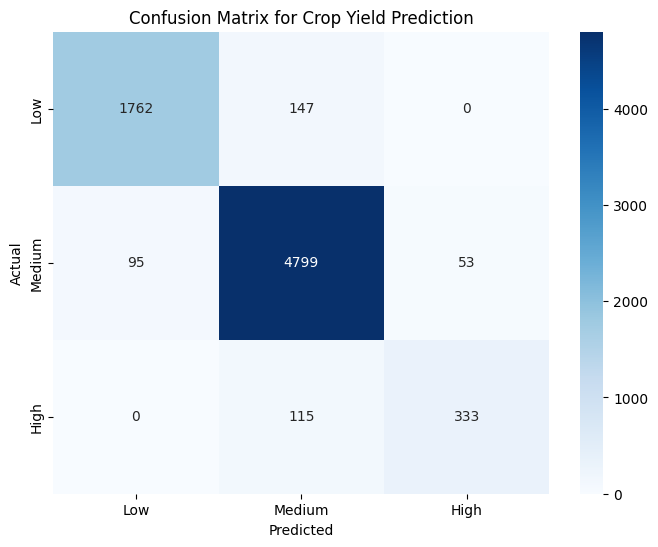

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.74      0.80       448
         Low       0.95      0.92      0.94      1909
      Medium       0.95      0.97      0.96      4947

    accuracy                           0.94      7304
   macro avg       0.92      0.88      0.90      7304
weighted avg       0.94      0.94      0.94      7304


Cross-validation Accuracy scores: [0.94199179 0.94574705 0.94848537 0.94300873 0.94780079]
Mean CV Accuracy: 0.9454067433925569
CV Accuracy Standard Deviation: 0.0025588115979796973

Top 10 Most Important Features for Classification:
             feature  importance
1        Temperature    0.365245
2           Humidity    0.200909
7       Soil_Quality    0.052162
10    Date_DayOfYear    0.045214
3         Wind_Speed    0.041485
5                  P    0.038483
21  Crop_Type_Tomato    0.035527
4                  N    0.030277
11         Date_Week    0.030241
8          Date_Year    0.02466

In [ ]:
# First, let's check for NaN values in the encoded features
print("NaN values in X_train_encoded:", X_train_encoded.isna().sum().sum())
print("NaN values in X_test_encoded:", X_test_encoded.isna().sum().sum())

# Check for NaN in the target variable
print("NaN values in y_train_class:", y_train_class.isna().sum())
print("NaN values in y_test_class:", y_test_class.isna().sum())

# Handle NaN values by filling them with appropriate values
# For numerical features, we'll use median
from sklearn.impute import SimpleImputer

# Create an imputer for numerical features
imputer = SimpleImputer(strategy='median')
X_train_encoded_imputed = imputer.fit_transform(X_train_encoded)
X_test_encoded_imputed = imputer.transform(X_test_encoded)

# Convert back to DataFrame to maintain column names
X_train_encoded_imputed = pd.DataFrame(X_train_encoded_imputed, columns=X_train_encoded.columns)
X_test_encoded_imputed = pd.DataFrame(X_test_encoded_imputed, columns=X_test_encoded.columns)

# Handle any NaN values in the target variable
y_train_class = y_train_class.fillna('Medium')  # Assuming Medium as default
y_test_class = y_test_class.fillna('Medium')

# Now train the classifier with the imputed data
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_classifier.fit(X_train_encoded_imputed, y_train_class)

# Make predictions
y_pred_class = rf_classifier.predict(X_test_encoded_imputed)

# Generate confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class, labels=yield_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=yield_labels, yticklabels=yield_labels)
plt.title('Confusion Matrix for Crop Yield Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

# Cross-validation for classification
cv_scores_class = cross_val_score(rf_classifier, X_train_encoded_imputed, y_train_class, 
                                 cv=5, scoring='accuracy')

print("\nCross-validation Accuracy scores:", cv_scores_class)
print("Mean CV Accuracy:", cv_scores_class.mean())
print("CV Accuracy Standard Deviation:", cv_scores_class.std())

# Feature importance for classification
feature_importances_class = rf_classifier.feature_importances_
importance_df_class = pd.DataFrame({
    'feature': X_train_encoded_imputed.columns,
    'importance': feature_importances_class
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features for Classification:")
print(importance_df_class.head(10))